# 02 - Data Cleaning

Applies the cleaning pipeline in `python/data_cleaning.py` to the raw dataset and inspects before/after data quality. Every cleaning decision is explained in `reports/cleaning_log.md`, generated by this same pipeline.

In [1]:
import sys, pandas as pd
sys.path.insert(0, '../python')
import data_cleaning as dc

raw = pd.read_csv('../data/raw/ev_charging_raw.csv')
print('Raw shape:', raw.shape)
raw.isna().sum().sort_values(ascending=False).head(8)

Raw shape: (85850, 25)


weather_condition       2579
waiting_time_minutes    1710
energy_consumed_kwh      855
charging_cost            854
vehicle_type             427
date                       0
start_time                 0
end_time                   0
dtype: int64

## Run the cleaning pipeline

In [2]:
cleaned, log_lines = dc.clean(raw.copy())
print('\nCleaned shape:', cleaned.shape)
cleaned.isna().sum().sum(), 'total remaining missing values'

Starting rows: 85850
Standardized energy_consumed_kwh to numeric (stripped stray unit text).
Parsed date/start_time/end_time to datetime; unparseable values become NaT for review.


Normalized station_name casing/whitespace by mapping to the most common clean name per station_id.


Removed 848 exact duplicate rows (ingestion retries).
Found 100 colliding session_id values; kept first occurrence, dropped 100 conflicting rows.
Fixed 338 negative energy_consumed_kwh values by taking absolute value (sign-flip entry error).
Fixed 339 negative revenue values by taking absolute value.
Nulled 170 waiting_time_minutes values > 480 min (sensor glitch, not realistic queue length).
Nulled 255 charging_duration_minutes values <= 0 (invalid session length).


Imputed 848 missing values in energy_consumed_kwh using group median of ['vehicle_type'] (fallback: global median).
Imputed 255 missing values in charging_duration_minutes using group median of ['vehicle_type', 'charger_type'] (fallback: global median).
Imputed 1865 missing values in waiting_time_minutes using group median of ['station_id'] (fallback: global median).
Imputed 850 missing values in charging_cost using group median of ['charger_type'] (fallback: global median).
Imputed 425 missing values in vehicle_type with 'Unknown' (avoids fabricating a specific category).
Imputed 2545 missing values in weather_condition with 'Unknown' (avoids fabricating a specific category).
Imputed 0 missing revenue values using group median by charger_type.
Capped 0 extreme outliers in energy_consumed_kwh at 83.18 (Q3 + 3xIQR winsorization).
Capped 2196 extreme outliers in charging_duration_minutes at 635.00 (Q3 + 3xIQR winsorization).
Capped 712 extreme outliers in waiting_time_minutes at 42.60 (Q

(np.int64(0), 'total remaining missing values')

## Before vs after: missing values per column

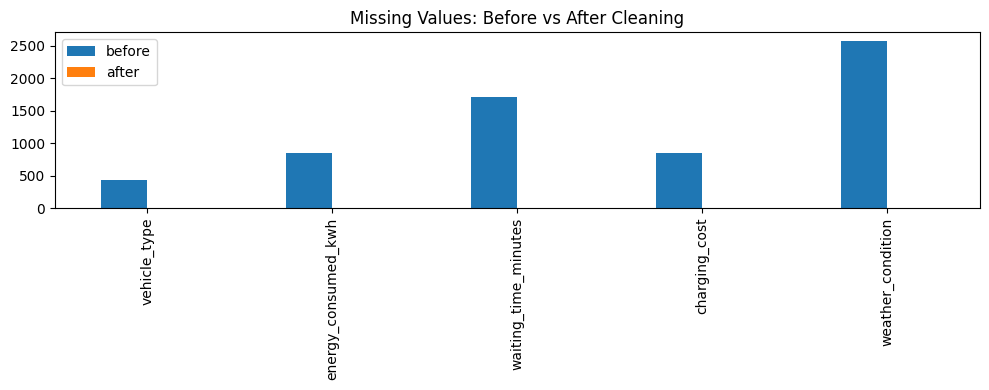

In [3]:
import matplotlib.pyplot as plt
before = raw.isna().sum()
after = cleaned.reindex(columns=raw.columns).isna().sum()
comp = pd.DataFrame({'before': before, 'after': after})
comp = comp[comp['before'] > 0]
comp.plot(kind='bar', figsize=(10,4), title='Missing Values: Before vs After Cleaning')
plt.tight_layout(); plt.show()

## Cleaning log (decision rationale)

In [4]:
for line in log_lines[:15]:
    print(line)

# Data Cleaning Log

Starting rows: 85850
Standardized energy_consumed_kwh to numeric (stripped stray unit text).
Parsed date/start_time/end_time to datetime; unparseable values become NaT for review.
Normalized station_name casing/whitespace by mapping to the most common clean name per station_id.
Removed 848 exact duplicate rows (ingestion retries).
Found 100 colliding session_id values; kept first occurrence, dropped 100 conflicting rows.
Fixed 338 negative energy_consumed_kwh values by taking absolute value (sign-flip entry error).
Fixed 339 negative revenue values by taking absolute value.
Nulled 170 waiting_time_minutes values > 480 min (sensor glitch, not realistic queue length).
Nulled 255 charging_duration_minutes values <= 0 (invalid session length).
Imputed 848 missing values in energy_consumed_kwh using group median of ['vehicle_type'] (fallback: global median).
Imputed 255 missing values in charging_duration_minutes using group median of ['vehicle_type', 'charger_type'] (f